# Build Equations of Motion from Euler-Lagrange

In [1]:
# symbolic computation tools
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np

import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

from sympy import init_printing
init_printing() 

Analyze EOM for a 2-link system

![text](diagram.png)

In [2]:
t = symbols("t" , real = True)
l0 = symbols("l0" , real = True)
m0 = symbols("m0" , real = True)
I0_xx = symbols("I0_xx" , real = True)
I0_yy = symbols("I0_yy" , real = True)
I0_zz = symbols("I0_zz" , real = True)
l1 = symbols("l1" , real = True)
m1 = symbols("m1" , real = True)
I1_xx = symbols("I1_xx" , real = True)
I1_yy = symbols("I1_yy" , real = True)
I1_zz = symbols("I1_zz" , real = True)
g = symbols("g" , real = True)

theta_1 = Function('theta_1', real=True)(t)
theta_0 = Function('theta_0', real=True)(t)
x = Function('x', real=True)(t)
y = Function('y', real=True)(t)

In [3]:
def cross_matrix(vec):
    
    return np.matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return np.matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return(m)

In [4]:
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])


def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])

In [5]:
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m

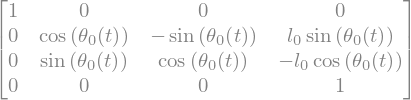

In [6]:
T_0 = T(R_x(theta_0), Matrix([[0], [0], [0]])) @ T(Matrix.eye(3,3), Matrix([[0], [0], [-l0]]))
T_0

### If want to tilt the pendulum
### T(R_y(-np.pi/8), Matrix([[0], [0], [0]])) @ 

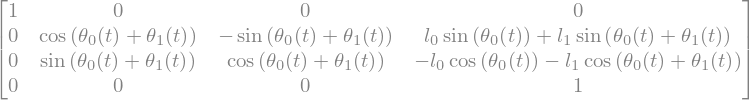

In [7]:
T_1 = T_0 @ T(R_x(theta_1), Matrix([[0], [0], [0]])) @ T(Matrix.eye(3,3), Matrix([[0], [0], [-l1]])) # Non-planar version
simplify(T_1)

In [8]:
# space_twist_1 = diff(T_1, t) @ T_1.inv()
# space_twist_1 = simplify(space_twist_1)
# space_twist_1

In [9]:
# twist2vec(space_twist_1)

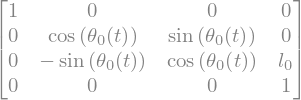

In [8]:
T_0_inv = Matrix.zeros(4,4)
T_0_inv[0:3, 0:3] = T_0[0:3,0:3].T
T_0_inv[0:3, 3] = -T_0[0:3,0:3].T @ T_0[0:3,3]
T_0_inv[3, 3] = 1
simplify(T_0_inv)

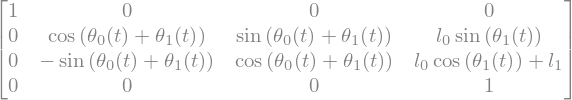

In [9]:
T_1_inv = Matrix.zeros(4,4)
T_1_inv[0:3, 0:3] = T_1[0:3,0:3].T
T_1_inv[0:3, 3] = -T_1[0:3,0:3].T @ T_1[0:3,3]
T_1_inv[3, 3] = 1
simplify(T_1_inv)

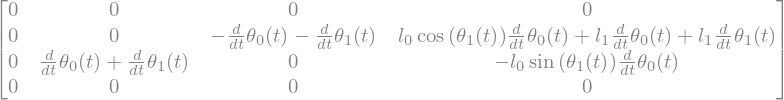

In [10]:
body_twist_1 = T_1_inv @ diff(T_1, t)
body_twist_1 = simplify(body_twist_1)
body_twist_1

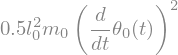

In [12]:
## Sum up the total energies

body_twist_0 = T_0_inv @ diff(T_0, t)
body_twist_0 = simplify(body_twist_0)
body_twist_0

body_twist_1 = T_1_inv @ diff(T_1, t)
body_twist_1 = simplify(body_twist_1)
body_twist_1

b0 = twist2vec(body_twist_0)
b1 = twist2vec(body_twist_1)

G_b_1 = Matrix([ [0*I1_xx, 0, 0, 0, 0, 0],
                 [0, I1_yy, 0, 0, 0, 0],
                 [0, 0, I1_zz, 0, 0, 0],
                 [0, 0, 0, m1, 0, 0],
                 [0, 0, 0, 0, m1, 0],
                 [0, 0, 0, 0, 0, m1]])
G_b_0 = Matrix([ [0*I0_xx, 0, 0, 0, 0, 0],
                 [0, I0_yy, 0, 0, 0, 0],
                 [0, 0, I0_zz, 0, 0, 0],
                 [0, 0, 0, m0, 0, 0],
                 [0, 0, 0, 0, m0, 0],
                 [0, 0, 0, 0, 0, m0]])


KE0 = .5 * b0.T @ G_b_0 @ b0
KE1 = .5 * b1.T @ G_b_1 @ b1 

simplify(KE0[0])

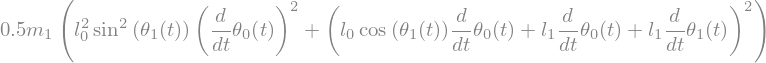

In [13]:
simplify(KE1[0])

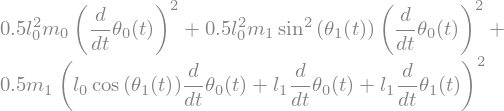

In [14]:
KE = simplify(KE0[0] + KE1[0])
KE

In [15]:
V = T_1[2, 3]*m1*g + T_0[2, 3]*m0*g
V

In [16]:
L = KE - V

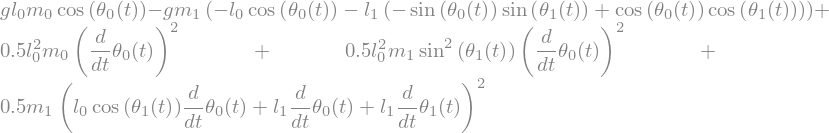

In [17]:
L

In [23]:
%qtconsole

## Assemble EOM from lagrangian

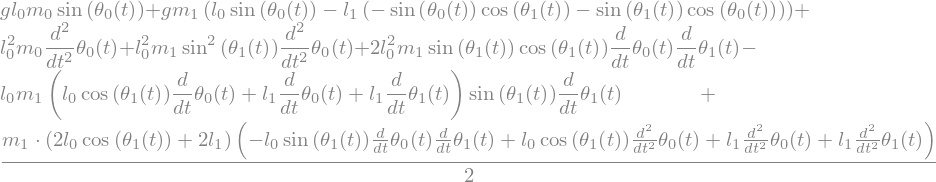

In [18]:
EOM_theta_0 = diff(diff(L, Derivative(theta_0, t)), t) - diff(L, theta_0)
EOM_theta_0 = nsimplify(EOM_theta_0)
EOM_theta_0

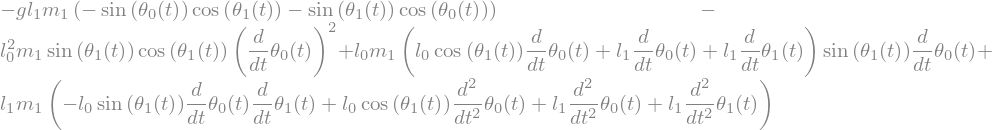

In [19]:
dl_dq_dot = diff(L, Derivative(theta_1, t))
EOM_theta_1 = diff(dl_dq_dot, t) - diff(L, theta_1)
EOM_theta_1 = nsimplify(EOM_theta_1)
EOM_theta_1

# Assemble the mass matrix and EOM

In [20]:
q = [theta_0, theta_1]
q_dt = [Derivative(qq, t) for qq in q]
q_dtdt = [Derivative(qq, t, t) for qq in q]

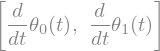

In [21]:
q_dt

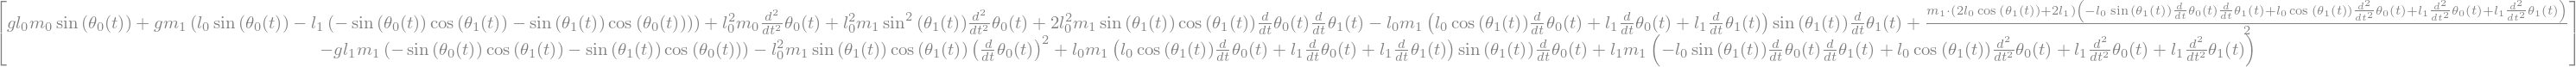

In [23]:
H = Matrix([[EOM_theta_0], [EOM_theta_1]])
H

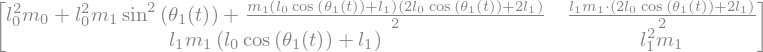

In [24]:
H.jacobian(q_dtdt)

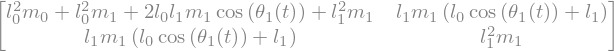

In [25]:
H = Matrix([[EOM_theta_0], [EOM_theta_1]])
mass = simplify(H.jacobian(q_dtdt))
mass

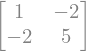

In [26]:
mass.subs([(l0,1), (l1,1),(m0,1),(m1,1),(theta_1,0)]).inv()

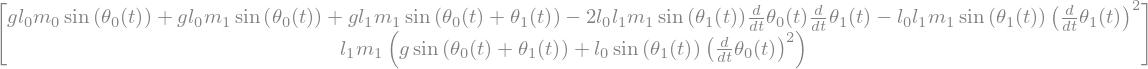

In [27]:
EOM = simplify(Matrix([[EOM_theta_0.expand()], 
                       [EOM_theta_1.expand()]]) - (mass @ Matrix(q_dtdt)))
EOM

In [157]:
%qtconsole

# Simulate the system

In [28]:
params = [l0, m0, I0_xx, I0_yy, I0_zz, l1, m1, I1_xx, I1_yy, I1_zz, g]

M_lambda       =   lambdify([q, q_dt, params], mass)
EOM_lambda     =   lambdify([q, q_dt, params], EOM)
KE_lambda      =   lambdify([q, q_dt, params], KE)
PE_lambda      =   lambdify([q, q_dt, params], V)

In [29]:
params_ = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 9.8]
q_ = [1, 1]
q_dt_ = [1, 1]

In [30]:
M_lambda(q_, q_dt_, params_)

array([[4.08060461, 1.54030231],
       [1.54030231, 1.        ]])

In [31]:
EOM_lambda(q_, q_dt_, params_)

array([[22.87953313],
       [ 9.75258577]])

In [32]:
def dynamics(t, state, params):
    theta_0, theta_1, theta_0_dot, theta_1_dot = state
    
    q    = [theta_0, theta_1]
    q_dt = [theta_0_dot, theta_1_dot]
    
    # dydt = np.linalg.inv(M_lambda(q, q_dt, params))@(-EOM_lambda(q, q_dt, params))
    dydt = np.linalg.solve(M_lambda(q, q_dt, params), -EOM_lambda(q, q_dt, params))

    return [theta_0_dot, theta_1_dot, dydt[0][0], dydt[1][0]]

In [33]:
dynamics(0, [1, 1, 1, 1], params_)

Text(0.5, 0, 'time')

/Users/nickgravish/anaconda3/lib/python3.11/site-packages/IPython/core/events.py:93: UserWarning: Glyph 9 (	) missing from current font.
  func(*args, **kwargs)


<Figure size 640x480 with 0 Axes>

/Users/nickgravish/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


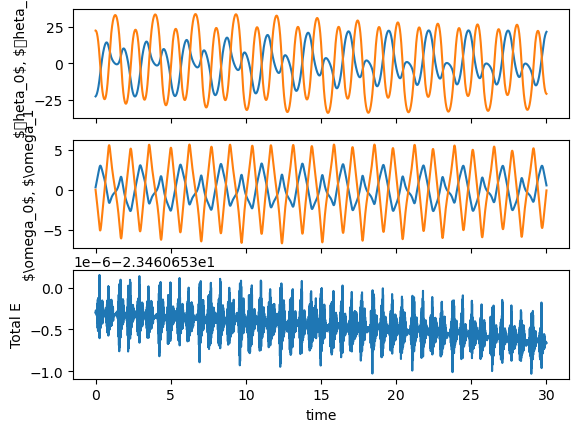

In [34]:
l0_ = 1
m0_ = 1
l1_ = 1
m1_ = 1
I0_xx_ = 0
I0_yy_ = 0
I0_zz_ = 0
I1_xx_ = 0
I1_yy_ = 0
I1_zz_ = 0
g_ = 9.8

params_ = [l0_, m0_, I0_xx_, I0_yy_, I0_zz_, l1_, m1_, I1_xx_, I1_yy_, I1_zz_, g_]

t_end = 30
dt = 0.001
time = np.linspace(0,t_end,int(t_end/dt))

init_state = [-np.pi/4, np.pi/4, .3, 0]

sol = solve_ivp(lambda t, y: dynamics(t, y, params_),
                [0,t_end], init_state, 
                t_eval = time, 
                rtol=1e-8, atol = 1e-8)

theta_0 = sol.y[0,:]
omega_0 = sol.y[2,:]
theta_1 = sol.y[1,:]
omega_1 = sol.y[3,:]

KE = [KE_lambda(st[0:2], st[2:], params_) for st in sol.y.T]
PE = [PE_lambda(st[0:2], st[2:], params_) for st in sol.y.T]

E_total = np.array(KE) + np.array(PE)

plt.clf()
f, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex = True)
ax1.plot(sol.t, theta_0*180/np.pi/2)
ax1.plot(sol.t, theta_1*180/np.pi/2)
ax1.set_ylabel('$\theta_0$, $\theta_1')

ax2.plot(sol.t, omega_0)
ax2.plot(sol.t, omega_1)
ax2.set_ylabel('$\omega_0$, $\omega_1')

ax3.plot(sol.t, E_total)
ax3.set_ylabel('Total E')

ax3.set_xlabel('time')

## Draw the simulation

In [64]:
%matplotlib qt

from mpl_toolkits import mplot3d


In [65]:
T_0_lambda = lambdify([q, q_dt, params], T_0)
T_1_lambda = lambdify([q, q_dt, params], T_1)

In [66]:
from PyQt5.QtWidgets import QApplication

plt.clf()

skip = 30

theta0 = sol.y[0,0:-1:skip]
theta1 = sol.y[1,0:-1:skip]

fig = plt.figure(1)
ax = plt.axes(projection='3d')

for kk, (q1, q2) in enumerate(zip(theta0, theta1)):
    plt.cla()
    # print(q1)
    
    T_0_ = T_0_lambda([q1, q2], [0, 0], params_)
    p_0_ = T_0_[:3,3]

    T_1_ = T_1_lambda([q1, q2], [0, 0], params_)
    p_1_ = T_1_[:3,3]

    
    ax.plot3D([0,p_0_[0]], [0, p_0_[1]], [0, p_0_[2]], 'ko-')
    ax.plot3D([p_0_[0], p_1_[0]], [p_0_[1], p_1_[1]], [p_0_[2], p_1_[2]], 'ko-')
    
    ax.axis('equal')

    ax.axes.set_xlim3d(-2,2)
    ax.axes.set_ylim3d(-2,2)
    ax.axes.set_zlim3d(-2,2)    

    plt.pause(0.00001)
    
    if plt.fignum_exists(fig.number) is False:
        print("Plot window closed, stopping loop.")
        break


qt.qpa.backingstore: Back buffer dpr of 1 doesn't match <NSViewBackingLayer: 0x6000000f09f0> contents scale of 2 - updating layer to match.
qt.qpa.backingstore: Back buffer dpr of 1 doesn't match <NSViewBackingLayer: 0x6000000d33f0> contents scale of 2 - updating layer to match.


In [ ]:
T_0_ = T_0_lambda([0, 0], [0, 0], params_)
T_0_

In [ ]:
T_0_[:3,3]

In [164]:
x

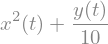

In [166]:
f = x**2 + y / 10
f

In [168]:
f_lamba = lambdify([x, y], f)

In [173]:
f_lamba(2, 20)